In [1]:
# 4.1
x = [1,2,3,10]
y = [10, 20, 30, 40]

z = [x + y for x, y in zip(x, y)]

print(z) 

def summation(x, y):
    return x + y

z2 = map(summation, x, y)

print(list(z2)) 

[11, 22, 33, 50]
[11, 22, 33, 50]


In [11]:
# 4.16
from scipy.integrate import quad
from astropy.cosmology import Planck18
from math import sqrt
from astropy import units as u

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

z = float(input("The redshift: "))


def F(z):
    return H0*sqrt(Om0*((1+z)**3)+Ode0)
    
def G(z):
    return (1/((1+z)*F(z)))

final, _ = quad(G, 0, z)

final2 = (final * u.Mpc * u.s/u.km).to(u.Gyr)

print(final2)

The redshift:  2


10.526203408163191 Gyr


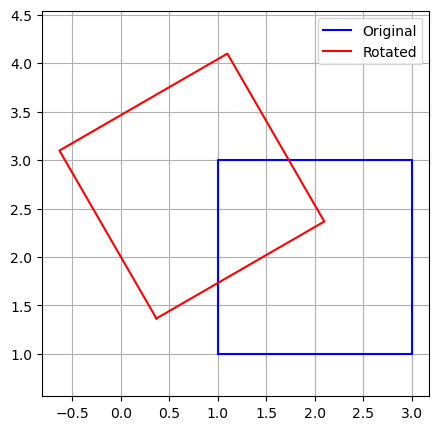

In [9]:
# 4.12
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

theta = 30
theta2 = np.deg2rad(theta)
rotor = np.exp(1j*theta2)

z = x + 1j*y
zrotation = z*rotor

x2 = zrotation.real
y2 = zrotation.imag

plt.figure(figsize=(5,5))
plt.plot(x, y, 'b-', label="Original")
plt.plot(x2, y2, 'r-', label = "Rotated")
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 4.3

import numpy as np

options = ["R", "P", "S"] 

initial = input("Enter your move (R for Rock, P for Paper, S for Scissors: ")

puter = np.random.choice(options)

print(f"Puter chose {puter}!")

if initial == puter:
    print("yall tied up buddy")
elif initial == "R" and puter == "S":
    print("win!")
elif initial == "P" and puter == "R":
    print("win!")
elif initial == "S" and puter == "P":
    print("win!")
else: 
    print("you lost my guy") 

Enter your move (R for Rock, P for Paper, S for Scissors:  R


Puter chose R!
yall tied up buddy


7.994457341885766
185.00203418074145


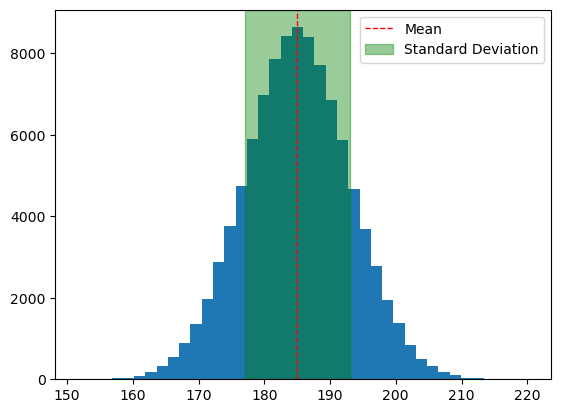

0.26598552904870054
0.6826894921370859


In [4]:
# 4.4

%matplotlib inline
import scipy.stats
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm

lengths = np.random.normal(185, 8, 100000)

sigma = np.std(lengths)
print(sigma)

mean = np.mean(lengths)
print(mean)

plt.hist(lengths, bins=40)
plt.axvline(x = mean, color='r', linestyle='dashed', linewidth=1, label = "Mean")
plt.axvspan(mean+sigma,mean-sigma, color = "g", alpha = 0.4, label = "Standard Deviation")
plt.legend()
plt.show()

h = 180
probh = scipy.stats.norm.cdf(h, 185, 8)
print(probh)

prob1std = scipy.stats.norm.cdf(185 + 8, 185, 8) - norm.cdf(185 - 8, 185, 8)
print(prob1std)

In [1]:
# 4.15
import numpy as np

def funcfilter(func, seq):
    arr = np.asarray(seq)
    filtered_arr = arr[arr>0]
    return func(filtered_arr)

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

single_sum = 100
result_single = funcfilter(np.log10, single_sum)
print(result_single)

Result log10: [1. 2.]
[2.]


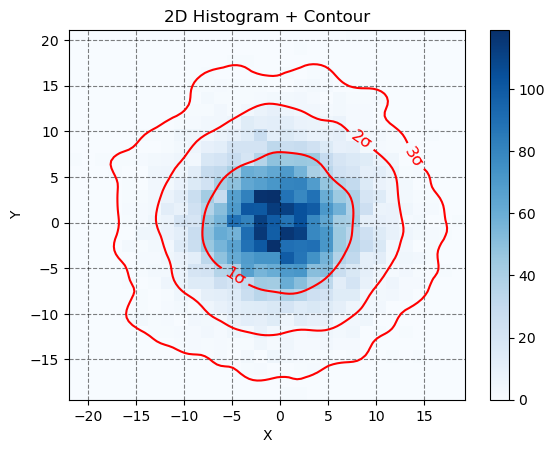

In [45]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import gaussian_kde

x = np.random.normal(0, 5, 10000)
y = np.random.normal(0, 5, 10000)

fig, ax = plt.subplots()

h = plt.hist2d(x, y, bins=30, cmap="Blues")
plt.colorbar(h[3])

k = gaussian_kde(np.vstack([x, y]))
xi, yi = np.mgrid[x.min():x.max():100j,y.min():y.max():100j]
zi = k(np.vstack([xi.flatten(),yi.flatten()]))

sorted_zi = np.sort(zi)
cumdensity = np.cumsum(sorted_zi)/np.sum(sorted_zi)
levels = [np.searchsorted(cumdensity, 1-p) for p in [0.997, 0.95, 0.68]]
levels = [sorted_zi[i] for i in levels]

CS = plt.contour(xi, yi, zi.reshape(xi.shape), levels = levels, colors ="red", linewidths = 1.5)

ax.clabel(CS, inline = True, fmt={levels[0]: "3σ", levels[1]:"2σ", levels[2]:"1σ"}, fontsize = 12)
          
plt.title("2D Histogram + Contour")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, linestyle="--", color = "black", alpha=0.5)
plt.show()


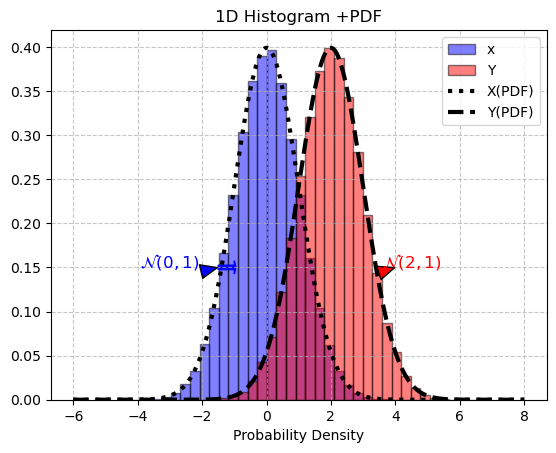

In [42]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import norm

np.random.seed(42)
x_data = np.random.normal(0, 1, 100000)
y_data = np.random.normal(2, 1, 100000)

fig, ax = plt.subplots()
bins = 30

plt.hist(x_data, bins=bins, density = True, alpha = 0.5, color = "blue", label = "x", edgecolor = "black")
plt.hist(y_data, bins=bins, density = True, alpha = 0.5, color = "red", label = "Y", edgecolor = "black")

x_range = np.linspace(-6, 8, 1000)
plt.plot(x_range, norm.pdf(x_range, 0, 1), "k:", linewidth=3, label = "X(PDF)")
plt.plot(x_range, norm.pdf(x_range, 2, 1), "k--", linewidth = 3, label = "Y(PDF)")

ax.arrow(-1.5, 0.15, 0.5, 0, width = 0.005, color = "blue", head_length = 0.05)

ax.annotate("$\mathcal{N}(0,1)$", xy =(-1.5, 0.15), xytext = (-3, 0.15), arrowprops = dict(facecolor = "blue", shrink = 0.05, width = 2, headwidth = 10), color = "blue", ha = "center", fontweight = "bold", fontsize = 12)
ax.annotate("$\mathcal{N}(2,1)$", xy =(4, 0.15), xytext = (4.5, 0.15), arrowprops = dict(facecolor = "red", shrink = 0.05, width = 2, headwidth = 10), color = "red", ha = "center", fontweight = "bold", fontsize = 12)

plt.title("1D Histogram +PDF")
plt.xlabel("Values")
plt.xlabel("Probability Density")
plt.legend()
plt.grid(True, linestyle="--", alpha = 0.7)
plt.show()



In [ ]:
import numpy as np

def montepython(func_str, a, b, n = 10000):

    x = np.random.uniform(a, b, n)

    y = eval(func_str)

    integral = (b-a)*np.mean(y)
    return integral

func = input("Here be function:")
a = float(input("Here be lower:"))
b = float(input("Here be upper:")) 

result = montepython(func, a, b)

print(result)

Here be function: x


In [29]:
# 4.6

from sympy import symbols, integrate, sympify 


integrand = input("enter ts here:")
var = input("enter var here:")
low = input("add a:")
up = input("add b:")
    
x = symbols(var) 
expr = sympify(integrand)
integral = integrate(expr,(x, low, up))
    
print(integral)




enter ts here: x
enter var here: x
add a: 0
add b: 1


1/2
